Part 1 — Popularity Recommender

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline

# Read data
df = pd.read_excel("Online Retail.xlsx")

# Shape
print(df.shape)

# Missing values
print(df.isnull().sum().sort_values(ascending=False))

# Remove missing values
df_new = df.dropna()

print(df_new.shape)

(541909, 8)
CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64
(406829, 8)


In [9]:
global_popularity = df_new.pivot_table(
    index=['StockCode','Description'],
    values='Quantity',
    aggfunc='sum'
).sort_values(by='Quantity', ascending=False)

print("Top 10 Popular Products")

print(global_popularity.head(10))

Top 10 Popular Products
                                              Quantity
StockCode Description                                 
84077     WORLD WAR 2 GLIDERS ASSTD DESIGNS      53215
85099B    JUMBO BAG RED RETROSPOT                45066
84879     ASSORTED COLOUR BIRD ORNAMENT          35314
85123A    WHITE HANGING HEART T-LIGHT HOLDER     34147
21212     PACK OF 72 RETROSPOT CAKE CASES        33409
22197     POPCORN HOLDER                         30504
23084     RABBIT NIGHT LIGHT                     27094
22492     MINI PAINT SET VINTAGE                 25880
22616     PACK OF 12 LONDON TISSUES              25321
21977     PACK OF 60 PINK PAISLEY CAKE CASES     24163


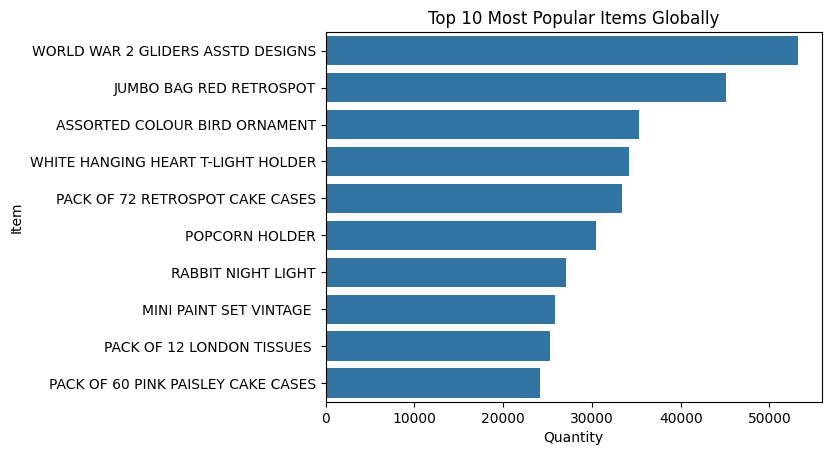

In [10]:
global_popularity.reset_index(inplace=True)

sns.barplot(
    y='Description',
    x='Quantity',
    data=global_popularity.head(10)
)

plt.title('Top 10 Most Popular Items Globally')
plt.ylabel('Item')
plt.show()

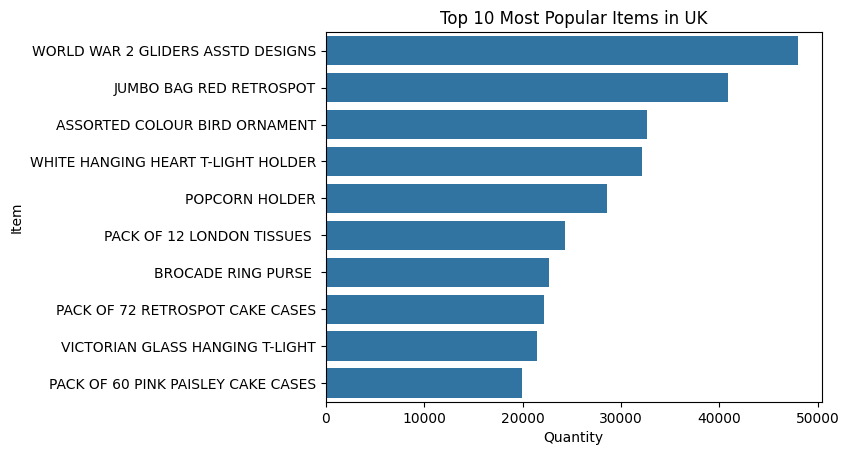

In [11]:
countrywise = df_new.pivot_table(

    index=['Country','StockCode','Description'],
    values='Quantity',
    aggfunc='sum'

).reset_index()

uk = countrywise[
    countrywise['Country']=='United Kingdom'
].sort_values(
    by='Quantity',
    ascending=False
).head(10)

sns.barplot(

    y='Description',
    x='Quantity',
    data=uk

)

plt.title('Top 10 Most Popular Items in UK')
plt.ylabel('Item')

plt.show()

In [12]:
def buy_again(customerid):

    items_bought = df_new[
        df_new['CustomerID']==customerid
    ].Description

    bought_again = Counter(items_bought)

    buy_again_list = list(bought_again)

    print("Items you would like to buy again:")

    return buy_again_list


buy_again(17850)

Items you would like to buy again:


['WHITE HANGING HEART T-LIGHT HOLDER',
 'WHITE METAL LANTERN',
 'CREAM CUPID HEARTS COAT HANGER',
 'KNITTED UNION FLAG HOT WATER BOTTLE',
 'RED WOOLLY HOTTIE WHITE HEART.',
 'SET 7 BABUSHKA NESTING BOXES',
 'GLASS STAR FROSTED T-LIGHT HOLDER',
 'HAND WARMER UNION JACK',
 'HAND WARMER RED POLKA DOT',
 'EDWARDIAN PARASOL RED',
 'RETRO COFFEE MUGS ASSORTED',
 'SAVE THE PLANET MUG',
 'VINTAGE BILLBOARD DRINK ME MUG',
 'VINTAGE BILLBOARD LOVE/HATE MUG',
 'WOOD 2 DRAWER CABINET WHITE FINISH',
 'WOOD S/3 CABINET ANT WHITE FINISH',
 'WOODEN PICTURE FRAME WHITE FINISH',
 'WOODEN FRAME ANTIQUE WHITE ',
 'EDWARDIAN PARASOL BLACK',
 'IVORY EMBROIDERED QUILT ',
 'JUMBO SHOPPER VINTAGE RED PAISLEY',
 'HAND WARMER RED RETROSPOT',
 'GIN AND TONIC MUG',
 'COLOUR GLASS. STAR T-LIGHT HOLDER',
 "YOU'RE CONFUSING ME METAL SIGN "]

Part 2 — Simple Recommender with the IMDB Metric

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("movies.csv")

df.head()

/tmp/ipykernel_4834/3390099420.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("movies.csv")


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [14]:
m = df['vote_count'].quantile(0.80)

print(m)

50.0


In [15]:
q_movies = df[
    (df['runtime'] >= 45) &
    (df['runtime'] <= 300)
]

q_movies = q_movies[
    q_movies['vote_count'] >= m
]

print(q_movies.shape)

(8963, 24)


In [16]:
C = df['vote_average'].mean()

print(C)

5.618207215134185


In [17]:
def weighted_rating(x, m=m, C=C):

    v = x['vote_count']

    R = x['vote_average']

    return (
        (v/(v+m) * R)
        +
        (m/(m+v) * C)
    )

In [18]:
q_movies['score'] = q_movies.apply(

    weighted_rating,

    axis=1

)

In [19]:
q_movies = q_movies.sort_values(

    'score',

    ascending=False

)

q_movies[
    ['title',
     'vote_count',
     'vote_average',
     'score',
     'runtime']

].head(25)

,title,vote_count,vote_average,score,runtime
10309,Dilwale Dulhania Le Jayenge,661.0,9.1,8.855148,190.0
314,The Shawshank Redemption,8358.0,8.5,8.482863,142.0
834,The Godfather,6024.0,8.5,8.476278,175.0
40251,Your Name.,1030.0,8.5,8.366584,106.0
12481,The Dark Knight,12269.0,8.3,8.289115,152.0
2843,Fight Club,9678.0,8.3,8.286216,139.0
292,Pulp Fiction,8670.0,8.3,8.284623,154.0
522,Schindler's List,4436.0,8.3,8.270109,195.0
23673,Whiplash,4376.0,8.3,8.269704,105.0
5481,Spirited Away,3968.0,8.3,8.266628,125.0


Part 3 — Individual Assessment: Ratings Data Analysis

In [20]:
import pandas as pd

df = pd.read_csv('Data1.csv', index_col=0)
movie_cols = df.columns[1:]

In [21]:
# Task 1: Mean Rating

mean_rating = df[movie_cols].mean()
mean_rating_sorted = mean_rating.sort_values(ascending=False)
print("TASK 1 - Mean Rating (Top 3):")
print(mean_rating_sorted.head(3))
print()

TASK 1 - Mean Rating (Top 3):
318: Shawshank Redemption, The (1994)             3.600000
260: Star Wars: Episode IV - A New Hope (1977)    3.266667
541: Blade Runner (1982)                          3.222222
dtype: float64



In [22]:
# Task 2: Rating Count (Popularity)

rating_count = df[movie_cols].count()
rating_count_sorted = rating_count.sort_values(ascending=False)
print("TASK 2 - Rating Count (Top 3):")
print(rating_count_sorted.head(3))
print()

TASK 2 - Rating Count (Top 3):
1: Toy Story (1995)                               17
593: Silence of the Lambs, The (1991)             16
260: Star Wars: Episode IV - A New Hope (1977)    15
dtype: int64



In [23]:
# Task 3: % of Ratings 4+ (Liking)

pct_4plus = (df[movie_cols] >= 4).sum() / df[movie_cols].count()
pct_4plus_sorted = pct_4plus.sort_values(ascending=False)
print("TASK 3 - % Ratings 4+ (Top 3):")
print(pct_4plus_sorted.head(3))
print()

TASK 3 - % Ratings 4+ (Top 3):
318: Shawshank Redemption, The (1994)             0.700000
260: Star Wars: Episode IV - A New Hope (1977)    0.533333
3578: Gladiator (2000)                            0.500000
dtype: float64



In [24]:
# Task 4: Mean Rating Difference by Gender

male_df = df[df['Gender'] == 0]
female_df = df[df['Gender'] == 1]

male_mean = male_df[movie_cols].mean()
female_mean = female_df[movie_cols].mean()
gender_diff = female_mean - male_mean        # positive = women rate higher
gender_diff_sorted = gender_diff.sort_values(ascending=False)

print("TASK 4 - Mean Rating Diff (female - male):")
print("Women rate highest above men:")
print(gender_diff_sorted.head(1))
print("Men rate highest above women:")
print(gender_diff_sorted.tail(1))

overall_male_mean = male_df[movie_cols].stack().mean()
overall_female_mean = female_df[movie_cols].stack().mean()
print(f"\nOverall male mean (all ratings): {overall_male_mean:.4f}")
print(f"Overall female mean (all ratings): {overall_female_mean:.4f}")
print(f"Overall diff (female - male): {overall_female_mean - overall_male_mean:.4f}")
print()


TASK 4 - Mean Rating Diff (female - male):
Women rate highest above men:
2396: Shakespeare in Love (1998)    2.107143
dtype: float64
Men rate highest above women:
1198: Raiders of the Lost Ark (1981)   -1.666667
dtype: float64

Overall male mean (all ratings): 2.9055
Overall female mean (all ratings): 2.9474
Overall diff (female - male): 0.0419



In [25]:
# Task 5: % of Ratings 4+ Difference by Gender

male_pct4 = (male_df[movie_cols] >= 4).sum() / male_df[movie_cols].count()
female_pct4 = (female_df[movie_cols] >= 4).sum() / female_df[movie_cols].count()
pct4_diff = female_pct4 - male_pct4
pct4_diff_sorted = pct4_diff.sort_values(ascending=False)

print("TASK 5 - % 4+ Diff (female - male):")
print("Women more likely:")
print(pct4_diff_sorted.head(1))
print("Men more likely:")
print(pct4_diff_sorted.tail(1))

male_overall_pct4 = (male_df[movie_cols].stack() >= 4).mean()
female_overall_pct4 = (female_df[movie_cols].stack() >= 4).mean()
print(f"\nOverall male % 4+: {male_overall_pct4:.4f}")
print(f"Overall female % 4+: {female_overall_pct4:.4f}")

TASK 5 - % 4+ Diff (female - male):
Women more likely:
2396: Shakespeare in Love (1998)    0.75
dtype: float64
Men more likely:
1198: Raiders of the Lost Ark (1981)   -0.5
dtype: float64

Overall male % 4+: 0.3386
Overall female % 4+: 0.4211
